In [3]:
import os
import shutil


In [4]:
# ============================================================
# SECTION 1 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# ============================================================
# SECTION 2 — DEFINE DATASET ZIP PATH
# ============================================================

ZIP_PATH = "/content/drive/MyDrive/Dataset/shezhen_datasets1.zip"

print("ZIP PATH:")
print(ZIP_PATH)

ZIP PATH:
/content/drive/MyDrive/Dataset/shezhen_datasets1.zip


In [9]:
# ============================================================
# SECTION 3 — EXTRACT ZIP FILE
# ============================================================

import zipfile
import os

EXTRACT_PATH = "/content/"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:

    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [17]:
# ============================================================
# SECTION 4 — VERIFY DATASET STRUCTURE
# ============================================================

# The previous BASE_PATH caused a FileNotFoundError.
# Let's inspect the extracted contents to find the correct path.

import os

# We know 'shezhen datasets' exists under /content/.
# We know 'shezhenv3-coco' exists under '/content/shezhen datasets/'.
# From the last output, it appears there's another 'shezhenv3-coco' directory inside that.
# Assuming the 'train' folder is inside the *inner* 'shezhenv3-coco',
# the correct BASE_PATH should be:
BASE_PATH = "/content/shezhen datasets/shezhenv3-coco/shezhenv3-coco/train"

print(f"Attempting to verify contents of: {BASE_PATH}\n")

# Now, let's verify the dataset structure with the updated BASE_PATH:
print("TRAIN FOLDER CONTENTS:")
if os.path.exists(BASE_PATH):
    for item in os.listdir(BASE_PATH):
        print(item)
else:
    print(f"Error: The specified BASE_PATH '{BASE_PATH}' still does not exist. Please double-check the actual directory structure within '/content/shezhen datasets/shezhenv3-coco/shezhenv3-coco/'.")

Attempting to verify contents of: /content/shezhen datasets/shezhenv3-coco/shezhenv3-coco/train

TRAIN FOLDER CONTENTS:
images
labels
annotations
classes.txt


In [19]:
# ============================================================
# SECTION 5 — READ CLASSES FILE
# ============================================================

classes_path = os.path.join(BASE_PATH, "classes.txt")

print("Reading classes file...\n")

with open(classes_path, 'r') as f:

    classes = f.readlines()

classes = [cls.strip() for cls in classes]

print("AVAILABLE CLASSES:\n")

for idx, cls in enumerate(classes):

    print(f"{idx}: {cls}")

Reading classes file...

AVAILABLE CLASSES:

0: jiankangshe
1: botaishe
2: hongshe
3: zishe
4: pangdashe
5: shoushe
6: hongdianshe
7: liewenshe
8: chihenshe
9: baitaishe
10: huangtaishe
11: heitaishe
12: huataishe
13: shenquao
14: shenqutu
15: gandanao
16: gandantu
17: piweiao
18: piweitu
19: xinfeitu
20: xinfeiao


In [20]:
# ============================================================
# SECTION 6 — FIND JSON FILE
# ============================================================

import glob

json_files = glob.glob(
    os.path.join(BASE_PATH, "**", "*.json"),
    recursive=True
)

print("FOUND JSON FILES:\n")

for file in json_files:

    print(file)

FOUND JSON FILES:

/content/shezhen datasets/shezhenv3-coco/shezhenv3-coco/train/annotations/train.json


In [21]:
# ============================================================
# SECTION 7 — LOAD COCO JSON
# ============================================================

import json

ANNOTATION_PATH = json_files[0]

with open(ANNOTATION_PATH, 'r') as f:

    coco_data = json.load(f)

print("COCO annotation loaded successfully.")

COCO annotation loaded successfully.


In [22]:
# ============================================================
# SECTION 8 — DATASET SUMMARY
# ============================================================

print("="*50)

print("DATASET SUMMARY")

print("="*50)

print("Total Images:")
print(len(coco_data['images']))

print("\nTotal Annotations:")
print(len(coco_data['annotations']))

print("\nTotal Categories:")
print(len(coco_data['categories']))

DATASET SUMMARY
Total Images:
5594

Total Annotations:
14677

Total Categories:
21


In [23]:
# ============================================================
# SECTION 9 — PRINT CATEGORY NAMES
# ============================================================

categories = coco_data['categories']

print("="*50)

print("AVAILABLE DATASET CATEGORIES")

print("="*50)

for cat in categories:

    print(
        f"ID: {cat['id']} | NAME: {cat['name']}"
    )

AVAILABLE DATASET CATEGORIES
ID: 0 | NAME: jiankangshe
ID: 1 | NAME: botaishe
ID: 2 | NAME: hongshe
ID: 3 | NAME: zishe
ID: 4 | NAME: pangdashe
ID: 5 | NAME: shoushe
ID: 6 | NAME: hongdianshe
ID: 7 | NAME: liewenshe
ID: 8 | NAME: chihenshe
ID: 9 | NAME: baitaishe
ID: 10 | NAME: huangtaishe
ID: 11 | NAME: heitaishe
ID: 12 | NAME: huataishe
ID: 13 | NAME: shenquao
ID: 14 | NAME: shenqutu
ID: 15 | NAME: gandanao
ID: 16 | NAME: gandantu
ID: 17 | NAME: piweiao
ID: 18 | NAME: piweitu
ID: 19 | NAME: xinfeiao
ID: 20 | NAME: xinfeitu


In [25]:
# ============================================================
# SECTION 10 — SELECT TARGET CLASSES
# ============================================================
TARGET_CLASSES = [

    'jiankangshe',
    'liewenshe',
    'baitaishe'

]
print("TARGET CLASSES:\n")

print(TARGET_CLASSES)

TARGET CLASSES:

['jiankangshe', 'liewenshe', 'baitaishe']


In [26]:
# ============================================================
# SECTION 11 — MAP CLASS IDS
# ============================================================

selected_ids = []

for cat in categories:

    if cat['name'] in TARGET_CLASSES:

        selected_ids.append(cat['id'])

print("SELECTED CATEGORY IDS:\n")

print(selected_ids)

SELECTED CATEGORY IDS:

[0, 7, 9]


In [27]:
# ============================================================
# SECTION 12 — FILTER ANNOTATIONS
# ============================================================

filtered_annotations = []

for ann in coco_data['annotations']:

    if ann['category_id'] in selected_ids:

        filtered_annotations.append(ann)

print("FILTERED ANNOTATIONS:")

print(len(filtered_annotations))

FILTERED ANNOTATIONS:
5693


In [28]:
# ============================================================
# SECTION 13 — GET IMAGE IDS
# ============================================================

selected_image_ids = set()

for ann in filtered_annotations:

    selected_image_ids.add(ann['image_id'])

print("RELEVANT IMAGE COUNT:")

print(len(selected_image_ids))

RELEVANT IMAGE COUNT:
4476


In [29]:
# ============================================================
# SECTION 14 — FILTER IMAGES
# ============================================================

filtered_images = []

for img in coco_data['images']:

    if img['id'] in selected_image_ids:

        filtered_images.append(img)

print("FILTERED IMAGE COUNT:")

print(len(filtered_images))

FILTERED IMAGE COUNT:
4476


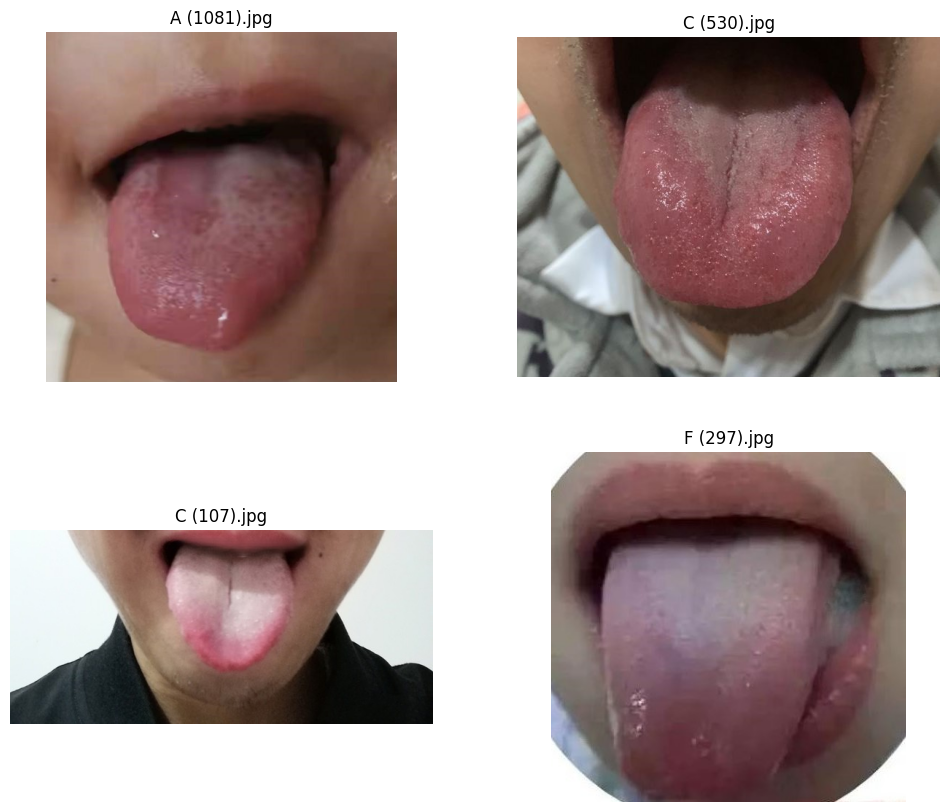

In [30]:
# ============================================================
# SECTION 15 — VISUALIZE SAMPLE IMAGES
# ============================================================

import cv2
import matplotlib.pyplot as plt
import random

IMAGE_FOLDER = os.path.join(BASE_PATH, "images")

sample_images = random.sample(
    filtered_images,
    min(4, len(filtered_images))
)

plt.figure(figsize=(12,10))

for i, img_info in enumerate(sample_images):

    img_path = os.path.join(
        IMAGE_FOLDER,
        img_info['file_name']
    )

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(img_info['file_name'])

    plt.axis('off')

plt.show()

In [34]:
# ============================================================
# SECTION 16 — CREATE FULL CURATED DATASET STRUCTURE
# ============================================================

"""
WHY?
-----
A proper curated dataset must contain:

- images
- annotations
- labels
- classes.txt

This preserves:
- training compatibility
- annotation integrity
- future preprocessing support

EXPECTED RESULT
----------------
Folder structure:

curated_dataset/
    images/
    annotations/
    labels/
"""

CURATED_PATH = "/content/curated_dataset"

CURATED_IMAGES = os.path.join(CURATED_PATH, "images")

CURATED_ANNOTATIONS = os.path.join(CURATED_PATH, "annotations")

CURATED_LABELS = os.path.join(CURATED_PATH, "labels")

os.makedirs(CURATED_IMAGES, exist_ok=True)

os.makedirs(CURATED_ANNOTATIONS, exist_ok=True)

os.makedirs(CURATED_LABELS, exist_ok=True)

print("Curated dataset folders created successfully.")

Curated dataset folders created successfully.


In [35]:
# ============================================================
# SECTION 17 — COPY FILTERED IMAGES
# ============================================================

"""
WHY?
-----
Copy only medically relevant images
into curated dataset.

EXPECTED RESULT
----------------
Only selected class images copied.
"""

import shutil

IMAGE_FOLDER = os.path.join(BASE_PATH, "images")

copied_count = 0

for img in filtered_images:

    filename = img['file_name']

    src = os.path.join(
        IMAGE_FOLDER,
        filename
    )

    dst = os.path.join(
        CURATED_IMAGES,
        filename
    )

    if os.path.exists(src):

        shutil.copy(src, dst)

        copied_count += 1

print(f"Copied {copied_count} curated images.")

Copied 4476 curated images.


In [36]:
# ============================================================
# SECTION 18 — SAVE CURATED ANNOTATIONS
# ============================================================

"""
WHY?
-----
Annotations preserve:
- class mappings
- category IDs
- image relationships

Without annotations:
dataset becomes unusable.

EXPECTED RESULT
----------------
Filtered COCO JSON saved.
"""

curated_coco = {

    'images': filtered_images,

    'annotations': filtered_annotations,

    'categories': [

        cat for cat in categories

        if cat['id'] in selected_ids
    ]
}

CURATED_JSON = os.path.join(
    CURATED_ANNOTATIONS,
    "curated_annotations.json"
)

with open(CURATED_JSON, 'w') as f:

    json.dump(curated_coco, f)

print("Curated annotation JSON saved.")

Curated annotation JSON saved.


In [37]:
# ============================================================
# SECTION 18.5 — COPY LABEL FILES
# ============================================================

"""
WHY?
-----
Some pipelines use YOLO label files.

We preserve labels for:
- future experiments
- object detection compatibility
- annotation integrity

EXPECTED RESULT
----------------
Matching label files copied.
"""

LABEL_FOLDER = os.path.join(BASE_PATH, "labels")

label_count = 0

for img in filtered_images:

    image_name = img['file_name']

    label_name = image_name.replace('.jpg', '.txt')

    src = os.path.join(
        LABEL_FOLDER,
        label_name
    )

    dst = os.path.join(
        CURATED_LABELS,
        label_name
    )

    if os.path.exists(src):

        shutil.copy(src, dst)

        label_count += 1

print(f"Copied {label_count} label files.")

Copied 4476 label files.


In [38]:
# ============================================================
# SECTION 18.6 — SAVE CURATED CLASSES
# ============================================================

"""
WHY?
-----
Preserve selected class names.

This helps:
- future training
- reproducibility
- documentation

EXPECTED RESULT
----------------
classes.txt saved in curated dataset.
"""

CURATED_CLASSES = os.path.join(
    CURATED_PATH,
    "classes.txt"
)

with open(CURATED_CLASSES, 'w') as f:

    for cls in TARGET_CLASSES:

        f.write(cls + '\n')

print("Curated classes.txt saved.")

Curated classes.txt saved.


In [39]:
# ============================================================
# SECTION 19 — VERIFY CURATED DATASET
# ============================================================

"""
WHY?
-----
Always verify dataset integrity
before downloading/training.

EXPECTED RESULT
----------------
Correct file counts.
"""

print("="*50)

print("CURATED DATASET SUMMARY")

print("="*50)

print("Selected Classes:")
print(TARGET_CLASSES)

print("\nCurated Images:")

print(len(os.listdir(CURATED_IMAGES)))

print("\nCurated Labels:")

print(len(os.listdir(CURATED_LABELS)))

print("\nAnnotation File Exists:")

print(os.path.exists(CURATED_JSON))

print("\nClasses File Exists:")

print(os.path.exists(CURATED_CLASSES))

CURATED DATASET SUMMARY
Selected Classes:
['jiankangshe', 'liewenshe', 'baitaishe']

Curated Images:
4476

Curated Labels:
4476

Annotation File Exists:
True

Classes File Exists:
True


In [40]:
# ============================================================
# SECTION 20 — ZIP AND DOWNLOAD CURATED DATASET
# ============================================================

"""
WHY?
-----
Create reusable research-ready dataset.

EXPECTED RESULT
----------------
Downloadable ZIP file containing:

- images
- annotations
- labels
- classes.txt
"""

ZIP_PATH = "/content/curated_dataset"

shutil.make_archive(

    ZIP_PATH,

    'zip',

    CURATED_PATH
)

print("Curated dataset zipped successfully.")

from google.colab import files

files.download("/content/curated_dataset.zip")

Curated dataset zipped successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>